In [1]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ascend_func(x):
    # smooth on [0, 1], with zero first derivative at both ends
    return jnp.where(
        x <= 0,
        0.0,
        jnp.where(
            x >= 1,
            1.0,
            0.5 * (1.0 - jnp.cos(jnp.pi * x))
        )
    )

def ascend_func_st(x):
    # stiff on [0, 1]
    return jnp.where(
        x <= 0,
        0.0,
        jnp.where(
            x >= 1,
            1.0,
            x
        )
    )

def make_modulation_funcs(ascend_func=ascend_func):
    # Set up time schedule for fixed time of adiabatic evolution
    def func_Omega(t, Omega, T):
        Omega_0 = 1.0

        x1 = t / (0.2 * T)                 # ramp from 0 to Omega_0 over [0, 0.2T]
        x3 = (t - 0.8 * T) / (0.2 * T)     # ramp from Omega_0 to Omega over [0.8T, T]

        y1 = Omega_0 * ascend_func(x1)
        y2 = Omega_0
        y3 = Omega_0 + (Omega - Omega_0) * ascend_func(x3)

        return jnp.where(
            t < 0.2 * T,
            y1,
            jnp.where(
                t < 0.8 * T,
                y2,
                y3
            )
        )

    def func_Delta(t, Delta, T):
        D0 = -1.0
        return D0 + (Delta - D0) * ascend_func((t - 0.2 * T) / (0.6 * T))
    
    def nudge_func(t, beta, T_nudge):
        #print(T_nudge)
        return beta * ascend_func(t/T_nudge)
    
    return func_Omega, func_Delta, nudge_func 

In [3]:
fO_sm, fD_sm, _ = make_modulation_funcs(ascend_func)
fO_st, fD_st, _ = make_modulation_funcs(ascend_func_st)

In [4]:
T = 1
Omega = 0.5
Delta = 0.8

tl = jnp.linspace(0, T, 100)

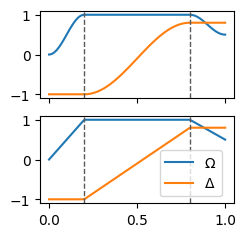

In [36]:
fig, ax = plt.subplots(2,1, figsize=(2.5, 2.5), sharex=True)

ax[0].plot(tl, fO_sm(tl, Omega, T))
ax[0].plot(tl, fD_sm(tl, Delta, T))

ax[1].plot(tl, fO_st(tl, Omega, T), label=r"$\Omega$")
ax[1].plot(tl, fD_st(tl, Delta, T), label=r"$\Delta$")

for axis in ax:
    for t_transition in (0.2, 0.8):
        axis.axvline(t_transition * T, color="0.35", linestyle="--", linewidth=1)

fig.legend(bbox_to_anchor=(0.88, 0.35))
fig.savefig("params_func.pdf", dpi=300)

In [37]:
2**16

65536